In [4]:
import xarray as xr
import json
import pandas as pd
import torch
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import os
import sys
sys.path.append('../')
import utils.evaluation as evaluation
import utils.utils as ut

In [2]:
# load true test data
settings_file_path = "../../settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)


### Factual ###
    
### Load temperature TEST data ###
ds_test_eth_fact_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht_eth_transient'])
ds_test_eth_fact = xr.open_dataset(ds_test_eth_fact_path)
ds_test_eth_fact

# load DAE ensemble
# ADJUST FOLLOWING PATH IF NECESSARY

dae_ensemble_fact = "_devicecuda100_6_100_100_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001_pene0/dae_ensemble_after_50_epochs/eth_ensemble_after_50_epochs/ETH_gen_dpa_ens_50_dataset_restored.nc"
dae_eth_fact_path = os.path.join(settings['paths']['output_dir'], dae_ensemble_fact)
dae_eth_fact = xr.open_dataset(dae_eth_fact_path) 
dae_eth_fact


### Counterfactual ###

### Load counterfactual temperature TEST data ###
ds_test_eth_cf_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht_eth_nudged_shifted'])
ds_test_eth_cf = xr.open_dataset(ds_test_eth_cf_path)
ds_test_eth_cf

# load DPA ensemble
# ADJUST FOLLOWING PATH IF NECESSARY
dae_ensemble_cf = "_devicecuda100_6_100_100_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001_pene0/dae_ensemble_after_50_epochs/eth_ensemble_after_50_epochs/ETH_cf_gen_dpa_ens_50_dataset_restored.nc"
dae_eth_cf_path = os.path.join(settings['paths']['output_dir'], dae_ensemble_cf)
dae_eth_cf = xr.open_dataset(dae_eth_cf_path) 


In [3]:
# compute domain average temperature
dae_eth_ens_spatial_mean = dae_eth_fact.TREFHT.mean(dim=("lat","lon"))
dae_eth_ens_spatial_mean_cf = dae_eth_cf.TREFHT.mean(dim=("lat","lon"))

fact_dae_mean = dae_eth_fact.TREFHT.mean(dim="ensemble_member")
cf_dae_mean = dae_eth_cf.TREFHT.mean(dim="ensemble_member")

## Maps

Date: 2036-06-27 00:00:00


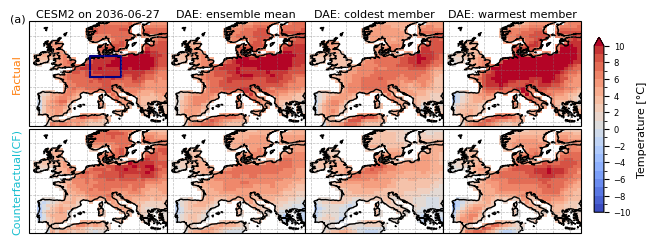

In [29]:
fact_dae_mean = dae_eth_fact.TREFHT.mean(dim="ensemble_member")
cf_dae_mean = dae_eth_cf.TREFHT.mean(dim="ensemble_member")

# Example dataset: ds.TREFHT should exist
date = 3539 #=year 2036
date_text = "2036-06-27"
print("Date:", ds_test_eth_fact.TREFHT.isel(time=date).time.values)

# Factual Fields
# find min and max values of domain average temperature
imin_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmin(dim="ensemble_member")
)
imax_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

field_factual = ds_test_eth_fact.TREFHT.isel(time=date)
field_1 = fact_dae_mean.isel(time=date)
field_2 = dae_eth_fact.TREFHT.isel(ensemble_member = imin_fact, time=date)
field_3 = dae_eth_fact.TREFHT.isel(ensemble_member = imax_fact, time=date)

# Counterfactual Fields

# find min and max values of domain average temperature
imin_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmin(dim="ensemble_member")
)
imax_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

field_cf = ds_test_eth_cf.TREFHT.isel(time=date)
field_1_cf = cf_dae_mean.isel(time=date)
field_2_cf = dae_eth_cf.TREFHT.isel(ensemble_member = imin_cf, time=date)
field_3_cf = dae_eth_cf.TREFHT.isel(ensemble_member = imax_cf, time=date)

# Plot parameters
vmin = -10
vmax = 10
no_levels=21
levels = np.linspace(vmin,vmax,no_levels)
cmap = "coolwarm"

text_fs = 8

# GER domain
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15


# Create figure and subplots
fig, axes = plt.subplots(
    2, 4,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(6.5,2.5)#(14, 6)
)


titles = [f"CESM2 on {date_text}", "DAE: ensemble mean", "DAE: coldest member", "DAE: warmest member", "", "", "", ""]
fields = [field_factual, field_1, field_2, field_3, field_cf, field_1_cf, field_2_cf, field_3_cf]
axes = axes.flatten()

for ax, field, title in zip(axes, fields, titles):
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False
    )
    

    if ax == axes[0]:
        lons = [ger_lon_min, ger_lon_max, ger_lon_max, ger_lon_min, ger_lon_min]
        lats = [ger_lat_min, ger_lat_min, ger_lat_max, ger_lat_max, ger_lat_min]
        ax.plot(
            lons, lats,
            transform=ccrs.PlateCarree(),
            color="navy",
            linewidth=1.5,
            linestyle="-"
        )
    ax.coastlines(resolution="50m", linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=text_fs, pad=3)


# tighten the grid (no whitespace)
fig.subplots_adjust(left=0.03, right=0.88, bottom=0.06, top=0.92,
                    wspace=0.0, hspace=0.0)

# create a dedicated axis for the colorbar: [left, bottom, width, height]
cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])

cbar = fig.colorbar(pc, cax=cax, orientation="vertical")
cbar.set_label("Temperature [°C]", fontsize=text_fs)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=6)

# Set tick positions
cbar.set_ticks(np.linspace(-10,10,11))

axes[0].text(-0.125, 0.5, f'Factual', transform=axes[0].transAxes,
              fontsize=text_fs, rotation=90, color="tab:orange", verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[4].text(-0.125, 0.5, f'Counterfactual(CF)', transform=axes[4].transAxes,
              fontsize=text_fs, rotation=90, color="tab:cyan", verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[0].text(-0.135,1,"(a)", transform=axes[0].transAxes, fontsize=text_fs)

fig.subplots_adjust(wspace=0.0, hspace=0.0)
plt.savefig(f"dpa_field_sample_{date_text}.pdf")
plt.show()


## Timeseries

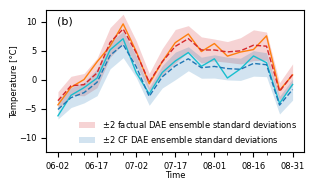

In [30]:
### Factual ###
year_tp = 2036
fig, ax = evaluation.plot_multiple_dpa_time_series(true_t = ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens = dae_eth_cf.TREFHT.isel(time=slice(0,4769)), 
                                          dpa_ens_mean = cf_dae_mean.isel(time=slice(0,4769)),  
                                          true_t_fact = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)),
                                          dpa_ens_fact = dae_eth_fact.isel(time=slice(0,4769)),
                                          dpa_ens_mean_fact = fact_dae_mean.isel(time=slice(0,4769)),
                                          lat_min = ger_lat_min, 
                                          lat_max = ger_lat_max, 
                                          lon_min = ger_lon_min, 
                                          lon_max = ger_lon_max, 
                                          plot_year = [str(year_tp)],
                                          figsize_ts = (3.25,2),
                                          title_fontsize = 6,
                                          title = f"Factual Temperatures Germany {year_tp}", 
                                          climate = "Counterfactual"
                                          )

### add factual time series ###
temp_true_ger_pre = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)).sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))

# create weights
# 1) define weights as above
weights_ger = np.cos(np.deg2rad(temp_true_ger_pre['lat']))

# 2) wrap in a DataArray so xarray knows which dim it belongs to
w_da_ger = xr.DataArray(weights_ger, coords={'lat': temp_true_ger_pre['lat']}, dims=['lat'])

temp_true_ger = temp_true_ger_pre.weighted(w_da_ger).mean(dim=('lat', 'lon'))

ax.set_ylabel("Temperature [°C]", fontsize = 6, labelpad=0)
ax.set_xlabel("Time", fontsize=6, labelpad=0)
ax.text(0.04,0.9,"(b)", transform=ax.transAxes, fontsize=text_fs)
plt.tick_params(axis='both', which='major', labelsize=6)
plt.ylim(-12.5,12)
plt.tight_layout()

# title
#plt.title(f"Mean temperatures Germany {year_tp}", fontsize=6)
#plt.legend()
plt.savefig(f"dpa_time_series_{year_tp}.pdf")
plt.show()

dae_ens_ger_1300: (1, 100)


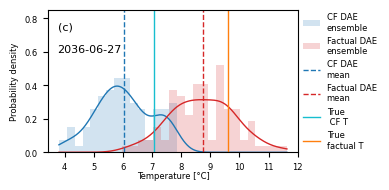

In [31]:


year = "2036"
dae_ens = dae_eth_cf.TREFHT.isel(time=slice(0,4769)).sel(time=slice(year,year))
dae_ens_fact = dae_eth_fact.isel(time=slice(0,4769)).sel(time=slice(year,year))

dae_ens_mean = cf_dae_mean.isel(time=slice(0,4769)).sel(time=slice(year,year))
dae_ens_mean_fact = fact_dae_mean.isel(time=slice(0,4769)).sel(time=slice(year,year))


lat_min = ger_lat_min 
lat_max = ger_lat_max
lon_min = ger_lon_min 
lon_max = ger_lon_max 
date=date_text

# ensemble mean, germany mean 
dae_ens_mean_ger = dae_ens_mean.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble germany average (ensemble_member, )
dae_ens_ger_1300 = dae_ens.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))
print("dae_ens_ger_1300:", dae_ens_ger_1300.values.T.shape)

# counterfactual truth
true_t = ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)).sel(time=date)
cf_truth_ger = true_t.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))




# ensemble mean, germany mean 
dae_ens_mean_ger_fact = dae_ens_mean_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble germany average (ensemble_member, )
dae_ens_ger_1300_fact = dae_ens_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).TREFHT.weighted(w_da_ger).mean(dim=('lat', 'lon'))

# factual truth
true_t_fact = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)).sel(time=date)
fact_truth_ger = true_t_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))


# Example data (replace with your own arrays)
a = dae_ens_ger_1300.values.flatten()
b = dae_ens_ger_1300_fact.values.flatten()

# Common bins
bins = np.linspace(
    min(a.min(), b.min()),
    max(a.max(), b.max()),
    30
)

fig, ax = plt.subplots(figsize=(4,2))

# Histograms (normalized)
ax.hist(
    a, bins=bins, density=True, #histtype="step",
     linewidth=1.5,
    label="CF DAE\nensemble", color="tab:blue", alpha=0.2
)
ax.hist(
    b, bins=bins, density=True, #histtype="step",
     linewidth=1.5,
    label="Factual DAE\nensemble", color="tab:red", alpha=0.2
)

# KDEs
x = np.linspace(bins[0], bins[-1], 500)
kde_a = gaussian_kde(a)
kde_b = gaussian_kde(b)

ax.plot(x, kde_a(x), linewidth=1, color="tab:blue")
ax.plot(x, kde_b(x), linewidth=1, color="tab:red")



# mean values
ax.axvline(
    x=dae_ens_mean_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:blue",
    linestyle="--",
    linewidth=1.0,
    label="CF DAE\nmean"
)

ax.axvline(
    x=dae_ens_mean_ger_fact.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:red",
    linestyle="--",
    linewidth=1.0,
    label="Factual DAE\nmean"
)



ax.axvline(
    x=cf_truth_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:cyan",
    linestyle="-",
    linewidth=1.0,
    label="True\n CF T"
)

ax.axvline(
    x=fact_truth_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:orange",
    linestyle="-",
    linewidth=1.0,
    label="True\nfactual T"
)



# Labels and legend
ax.set_xlabel("Temperature [°C]", fontsize=6, labelpad=0)
ax.set_ylabel("Probability density", fontsize=6)
ax.tick_params(axis="x", labelsize=6)
ax.tick_params(axis="y", labelsize=6)
ax.text(0.04,0.7,f"(c)\n\n{date}", transform=ax.transAxes, fontsize=text_fs)


ax.legend(
    loc="center left",
    bbox_to_anchor=(0.99, 0.5),
    frameon=False,
    fontsize=6
)

fig.subplots_adjust(right=0.75)

#ax.set_xlim(-1,5)
ax.set_ylim(0.0, 0.85)

plt.tight_layout()
#plt.savefig(f"T_distrs_{date_text}.pdf")
plt.show()


## Add risk-based distributions

In [32]:
# load large ensemble temperatures


# Factual
ds_test_le_fact_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht'])
ds_test_le_fact = xr.open_dataset(ds_test_le_fact_path)
ds_test_le_fact

# unstack time --> ensemble members

# ds dims: time=476900, lat=32, lon=32
n_ens = 100
n_t = 4769

if ds_test_le_fact.sizes["time"] != n_ens * n_t:
    raise ValueError("time dimension does not match 100 * 4769")

# build ensemble and within-member time-step labels
ens = np.repeat(np.arange(1, n_ens + 1), n_t)
t_in_ens = np.tile(np.arange(n_t), n_ens)

# replace the 1D time index by a MultiIndex, then unstack
ds_test_le_fact_unstacked = (
    ds_test_le_fact.assign_coords(
        time=pd.MultiIndex.from_arrays(
            [ens, t_in_ens],
            names=["member", "time_in_member"]
        )
    )
    .unstack("time")
    .assign_coords(time_in_member=ds_test_le_fact.isel(time=slice(0,4769)).time.values)
)

# factual distribution (2011-2061)
trefht_le_fact_2011_61 = ds_test_le_fact_unstacked.TREFHT.sel(time_in_member=slice("2011", "2061"))

trefht_le_fact_0627 = trefht_le_fact_2011_61.sel(
    time_in_member=(trefht_le_fact_2011_61.time_in_member.dt.month == 6) & (trefht_le_fact_2011_61.time_in_member.dt.day == 27)
)
trefht_le_fact_0627

# counterfactual distribution
trefht_le_fact_1850_1900 = ds_test_le_fact_unstacked.TREFHT.sel(time_in_member=slice("1850", "1900"))

trefht_le_cf_0627 = trefht_le_fact_1850_1900.sel(
    time_in_member=(trefht_le_fact_1850_1900.time_in_member.dt.month == 6) & (trefht_le_fact_1850_1900.time_in_member.dt.day == 27)
)
trefht_le_cf_0627






/tmp/ipykernel_1759516/615201801.py:24: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'time' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  ds_test_le_fact.assign_coords(


<xarray.DataArray 'TREFHT' (lat: 32, lon: 32, member: 100, time_in_member: 51)> Size: 21MB
array([[[[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
...
          -0.997406  ,  1.7683105 ],
         [-1.2379761 ,  1.016571  ,  1.8097229 , ...,  0.7380676 ,
           0.6995239 ,  0.31402588],
         [-2.7175903 ,  3.0505981 ,  3.0550232 , ...,  8.026276  ,
          -3.3776245 ,  2.5436707 ]],

        [[-0.73828125, -4.2813416 ,  1.8380737 , ..., -0.37365723,
          -6.226898  ,  1.4903259 ],
         [ 5.494049  , -3.63089   ,  1.924408  , ...,  2.9640198 ,
           4.156189  , -1.9683838 ],
         [ 0.80700684,  7.1707764 ,  1.2277222 , ...,  3.4256897 ,
          -1.3093262 ,  1.1897278 ],
         ...,
         [ 1.2711182 , -0.05834961, -1.7219543 , ..., -2.9446106 ,
          -1.1953735 ,  2.1548767 ],
         [-1.1790771 ,  0.921875  ,  2.2159424 , ...,  1.0066528 ,
           1.003418  ,  0.11166382],
         [-2.84964   ,  3.5766602 ,  2.7470398 , ...,  8.055847  ,
          -3.7910767 ,  3.110199  ]]]],
      shape=(32, 32, 100, 51), dtype=float32)
Coordinates:
  * member          (member) int64 800B 1 2 3 4 5 6 7 ... 94 95 96 97 98 99 100
  * lon             (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
  * lat             (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * time_in_member  (time_in_member) object 408B 1850-06-27 00:00:00 ... 1900...

In [33]:
trefht_le_fact_0627_ger = ut.get_ger_1d_data(trefht_le_fact_0627)
trefht_le_cf_0627_ger = ut.get_ger_1d_data(trefht_le_cf_0627)

trefht_le_fact_0627_ger
trefht_le_cf_0627_ger

<xarray.DataArray 'TREFHT' (member: 100, time_in_member: 51)> Size: 41kB
array([[ 0.5982974 ,  3.58383492, -2.2390304 , ...,  1.31531295,
        -0.51897073,  4.4869289 ],
       [-1.07830706,  3.92573665,  4.36482211, ..., -3.78487479,
        -2.73280664, -0.40980706],
       [-2.58659608, -0.26951288,  4.53340401, ...,  0.88647014,
         1.76728826, -0.27935691],
       ...,
       [ 0.34781491,  1.56559358,  3.02928775, ...,  2.83639512,
        -0.41292424, -0.23337297],
       [ 0.10563499,  0.20844499,  0.05333959, ..., -2.8865407 ,
         1.99450361,  1.61876341],
       [ 2.83381045,  2.42371727,  1.74131216, ...,  2.21019133,
        -1.67363819,  1.03980132]], shape=(100, 51))
Coordinates:
  * member          (member) int64 800B 1 2 3 4 5 6 7 ... 94 95 96 97 98 99 100
  * time_in_member  (time_in_member) object 408B 1850-06-27 00:00:00 ... 1900...

dae_ens_ger_1300: (1, 100)


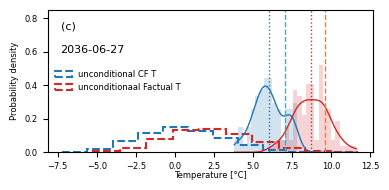

In [38]:


year = "2036"
dae_ens = dae_eth_cf.TREFHT.isel(time=slice(0,4769)).sel(time=slice(year,year))
dae_ens_fact = dae_eth_fact.isel(time=slice(0,4769)).sel(time=slice(year,year))

dae_ens_mean = cf_dae_mean.isel(time=slice(0,4769)).sel(time=slice(year,year))
dae_ens_mean_fact = fact_dae_mean.isel(time=slice(0,4769)).sel(time=slice(year,year))


lat_min = ger_lat_min 
lat_max = ger_lat_max
lon_min = ger_lon_min 
lon_max = ger_lon_max 
date=date_text

# ensemble mean, germany mean 
dae_ens_mean_ger = dae_ens_mean.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble germany average (ensemble_member, )
dae_ens_ger_1300 = dae_ens.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))
print("dae_ens_ger_1300:", dae_ens_ger_1300.values.T.shape)

# counterfactual truth
true_t = ds_test_eth_cf.TREFHT.isel(time=slice(0,4769)).sel(time=date)
cf_truth_ger = true_t.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))




# ensemble mean, germany mean 
dae_ens_mean_ger_fact = dae_ens_mean_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).weighted(w_da_ger).mean(dim=('lat', 'lon'))

# ensemble germany average (ensemble_member, )
dae_ens_ger_1300_fact = dae_ens_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).sel(time=date).TREFHT.weighted(w_da_ger).mean(dim=('lat', 'lon'))

# factual truth
true_t_fact = ds_test_eth_fact.TREFHT.isel(time=slice(0,4769)).sel(time=date)
fact_truth_ger = true_t_fact.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)).weighted(w_da_ger).mean(dim=('lat', 'lon'))


# Example data (replace with your own arrays)
a = dae_ens_ger_1300.values.flatten()
b = dae_ens_ger_1300_fact.values.flatten()

# Common bins
bins = np.linspace(
    min(a.min(), b.min()),
    max(a.max(), b.max()),
    30
)

fig, ax = plt.subplots(figsize=(4,2))

# Histograms (normalized)
ax.hist(
    a, bins=bins, density=True, #histtype="step",
     linewidth=1.5,
    #label="CF DAE\nensemble",
    color="tab:blue", alpha=0.2
)
ax.hist(
    b, bins=bins, density=True, #histtype="step",
     linewidth=1.5,
    #label="Factual DAE\nensemble",
    color="tab:red", alpha=0.2
)


#############################
### risk-based Histograms ###
#############################
a_risk = trefht_le_cf_0627_ger.values.flatten()
b_risk = trefht_le_fact_0627_ger.values.flatten()

ax.hist(
    a_risk,
    density=True,
    histtype="step",
    linewidth=1.5,
    label="unconditional CF T",
    color="tab:blue",
    linestyle="--"
)

ax.hist(
    b_risk,
    density=True,
    histtype="step",
    linewidth=1.5,
    label="unconditionaal Factual T",
    color="tab:red",
    linestyle="--"
)

# KDEs
x = np.linspace(bins[0], bins[-1], 500)
kde_a = gaussian_kde(a)
kde_b = gaussian_kde(b)

ax.plot(x, kde_a(x), linewidth=1, color="tab:blue")
ax.plot(x, kde_b(x), linewidth=1, color="tab:red")



# mean values
ax.axvline(
    x=dae_ens_mean_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:blue",
    linestyle=":",
    linewidth=1.0,
    #label="CF DAE\nmean"
)

ax.axvline(
    x=dae_ens_mean_ger_fact.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:red",
    linestyle=":",
    linewidth=1.0,
    #label="Factual DAE\nmean"
)



ax.axvline(
    x=cf_truth_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:cyan",
    linestyle="--",
    linewidth=1.0,
    #label="True\n CF T"
)

ax.axvline(
    x=fact_truth_ger.values,
    ymin=0.0,
    ymax=1.0,
    color="tab:orange",
    linestyle="--",
    linewidth=1.0,
    #label="True\nfactual T"
)



# Labels and legend
ax.set_xlabel("Temperature [°C]", fontsize=6, labelpad=0)
ax.set_ylabel("Probability density", fontsize=6)
ax.tick_params(axis="x", labelsize=6)
ax.tick_params(axis="y", labelsize=6)
ax.text(0.04,0.7,f"(c)\n\n{date}", transform=ax.transAxes, fontsize=text_fs)


ax.legend(
    loc="center left",
    frameon=False,
    fontsize=6
)

fig.subplots_adjust(right=0.75)

#ax.set_xlim(-1,5)
ax.set_ylim(0.0, 0.85)

plt.tight_layout()
plt.savefig(f"T_distrs_and_risk_{date_text}.pdf")
plt.show()


dates: [cftime.DatetimeNoLeap(2036, 6, 2, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 6, 7, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 6, 12, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 6, 17, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 6, 22, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 6, 27, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 7, 2, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 7, 7, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 7, 12, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 7, 17, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 7, 22, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 7, 27, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 8, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 8, 6, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2036, 8, 11, 0, 0, 0, 0,

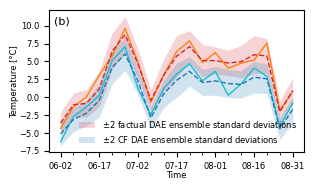

/tmp/ipykernel_1759516/502367283.py:334: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x=float(cf_truth_ger.values),
/tmp/ipykernel_1759516/502367283.py:341: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x=float(fact_truth_ger.values),


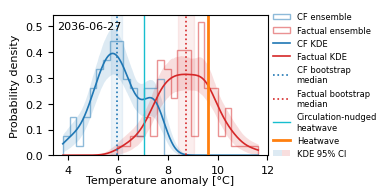

In [39]:
from matplotlib.patches import Patch

#importlib.reload(evaluation)

# ---------------------------------------------------------------------
# Region settings
# ---------------------------------------------------------------------
LAT_MIN, LAT_MAX = 48, 54
LON_MIN, LON_MAX = 6, 15

TIME_SLICE = slice(0, 4769)
YEAR = 2036
DATE = "2036-06-27"

N_BOOT = 2000
ALPHA = 0.05
TEXT_FS = text_fs  # assumes text_fs already exists in your notebook/script

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def area_weighted_mean(data, lat_min, lat_max, lon_min, lon_max, time=None):
    """Compute cosine-latitude weighted regional mean."""
    regional = data.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    if time is not None:
        regional = regional.sel(time=time)

    weights = np.cos(np.deg2rad(regional["lat"]))
    weights_da = xr.DataArray(weights, coords={"lat": regional["lat"]}, dims=["lat"])

    return regional.weighted(weights_da).mean(dim=("lat", "lon"))


def bootstrap_median(values, n_boot=1000, alpha=0.05, rng=None):
    """
    Bootstrap the sample median and return:
    - median of bootstrap medians
    - lower / upper CI of bootstrap medians
    - all bootstrap medians
    """
    values = np.asarray(values).ravel()
    n = values.size

    if rng is None:
        rng = np.random.default_rng()

    boot_medians = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot_medians[i] = np.median(sample)

    lower_q = 100 * (alpha / 2)
    upper_q = 100 * (1 - alpha / 2)

    median_of_medians = np.median(boot_medians)
    ci_low = np.percentile(boot_medians, lower_q)
    ci_high = np.percentile(boot_medians, upper_q)

    return median_of_medians, ci_low, ci_high, boot_medians


def bootstrap_kde_ci(samples, x_grid, n_boot=1000, alpha=0.05, rng=None, bw_method=None):
    """
    Bootstrap pointwise confidence intervals for a Gaussian KDE.

    Returns
    -------
    kde_ref : ndarray
        KDE estimated from the original sample.
    kde_low : ndarray
        Lower pointwise confidence bound.
    kde_high : ndarray
        Upper pointwise confidence bound.
    kde_boot : ndarray
        All bootstrap KDE evaluations.
    """
    samples = np.asarray(samples).ravel()
    n = samples.size

    if rng is None:
        rng = np.random.default_rng()

    kde_boot = np.empty((n_boot, len(x_grid)), dtype=float)

    for i in range(n_boot):
        resample = rng.choice(samples, size=n, replace=True)
        kde = gaussian_kde(resample, bw_method=bw_method)
        kde_boot[i] = kde(x_grid)

    kde_ref = gaussian_kde(samples, bw_method=bw_method)(x_grid)

    lower_q = 100 * (alpha / 2)
    upper_q = 100 * (1 - alpha / 2)

    kde_low = np.percentile(kde_boot, lower_q, axis=0)
    kde_high = np.percentile(kde_boot, upper_q, axis=0)

    return kde_ref, kde_low, kde_high, kde_boot


# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
cf_truth_all = ds_test_eth_cf.isel(time=TIME_SLICE).TREFHT
cf_ensemble_all = dae_eth_cf.isel(time=TIME_SLICE).TREFHT
cf_ensemble_mean_all = cf_dae_mean.isel(time=TIME_SLICE)

fact_truth_all = ds_test_eth_fact.isel(time=TIME_SLICE).TREFHT
fact_ensemble_all = dae_eth_fact.isel(time=TIME_SLICE)
fact_ensemble_mean_all = fact_dae_mean.isel(time=TIME_SLICE)

print("dates:", cf_truth_all.sel(time=str(YEAR)).time.values)

# ---------------------------------------------------------------------
# Time series panel
# ---------------------------------------------------------------------
fig, ax = evaluation.plot_multiple_dpa_time_series(
    true_t=cf_truth_all,
    dpa_ens=cf_ensemble_all,
    dpa_ens_mean=cf_ensemble_mean_all,
    true_t_fact=fact_truth_all,
    dpa_ens_fact=fact_ensemble_all,
    dpa_ens_mean_fact=fact_ensemble_mean_all,
    lat_min=LAT_MIN,
    lat_max=LAT_MAX,
    lon_min=LON_MIN,
    lon_max=LON_MAX,
    plot_year=[str(YEAR)],
    figsize_ts=(3.25,2), #(3.25, 2),
    title_fontsize=6,
    title=f"Factual Temperatures Germany {YEAR}",
    climate="Counterfactual",
)

ax.set_ylabel("Temperature [°C]", fontsize=6, labelpad=0)
ax.set_xlabel("Time", fontsize=6, labelpad=0)
ax.text(0.02, 0.9, "(b)", transform=ax.transAxes, fontsize=TEXT_FS)
ax.tick_params(axis="both", which="major", labelsize=6)

plt.tight_layout()
#plt.savefig("hw_timeseries.pdf")

plt.show()

# ---------------------------------------------------------------------
# Regional averages on selected date
# ---------------------------------------------------------------------
# Counterfactual
cf_single_ensemble_mean_ger = area_weighted_mean(
    cf_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_ensemble_members_ger = area_weighted_mean(
    cf_ensemble_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_truth_ger = area_weighted_mean(
    cf_truth_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

# Factual
fact_single_ensemble_mean_ger = area_weighted_mean(
    fact_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
fact_ensemble_members_ger = area_weighted_mean(
    fact_ensemble_all.TREFHT, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
fact_truth_ger = area_weighted_mean(
    fact_truth_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

cf_values = cf_ensemble_members_ger.values.ravel()
fact_values = fact_ensemble_members_ger.values.ravel()

# ---------------------------------------------------------------------
# Bootstrap medians
# ---------------------------------------------------------------------
cf_boot_median, cf_median_ci_low, cf_median_ci_high, cf_boot_medians = bootstrap_median(
    cf_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(42),
)

fact_boot_median, fact_median_ci_low, fact_median_ci_high, fact_boot_medians = bootstrap_median(
    fact_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(43),
)

# ---------------------------------------------------------------------
# KDE + bootstrap KDE confidence intervals
# ---------------------------------------------------------------------
bins = np.linspace(
    min(cf_values.min(), fact_values.min()),
    max(cf_values.max(), fact_values.max()),
    30,
)
x = np.linspace(bins[0], bins[-1], 500)

# Optional fixed bandwidth for more stable bootstrap-KDE CIs
cf_bw = gaussian_kde(cf_values).factor
fact_bw = gaussian_kde(fact_values).factor

cf_kde, cf_kde_low, cf_kde_high, _ = bootstrap_kde_ci(
    cf_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(44),
    bw_method=cf_bw,
)

fact_kde, fact_kde_low, fact_kde_high, _ = bootstrap_kde_ci(
    fact_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(45),
    bw_method=fact_bw,
)

# ---------------------------------------------------------------------
# Plot histogram + KDE CI + mean/median/truth lines
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(4,2))

# Histograms as one-line outlines
ax.hist(
    cf_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1,
    alpha=0.5,
    color="tab:blue",
    label="CF ensemble",
)
ax.hist(
    fact_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1,
    alpha=0.5,
    color="tab:red",
    label="Factual ensemble",
)

# KDE confidence intervals
ax.fill_between(
    x,
    cf_kde_low,
    cf_kde_high,
    color="tab:blue",
    alpha=0.15,
    linewidth=0,
    #label="CF KDE 95% CI",
)
ax.fill_between(
    x,
    fact_kde_low,
    fact_kde_high,
    color="tab:red",
    alpha=0.15,
    linewidth=0,
    #label="Factual KDE 95% CI",
)

# KDE lines from original ensemble
ax.plot(
    x,
    cf_kde,
    color="tab:blue",
    linewidth=1.2,
    label="CF KDE",
)
ax.plot(
    x,
    fact_kde,
    color="tab:red",
    linewidth=1.2,
    label="Factual KDE",
)

# Single ensemble mean vertical lines
#ax.axvline(
#    x=float(cf_single_ensemble_mean_ger.values),
#    color="tab:blue",
#    linestyle="--",
#    linewidth=1.0,
#    label="CF single\nensemble mean",
#)
#ax.axvline(
#    x=float(fact_single_ensemble_mean_ger.values),
#    color="tab:red",
#    linestyle="--",
#    linewidth=1.0,
#    label="Factual single\nensemble mean",
#)

# Bootstrap median vertical lines
ax.axvline(
    x=float(cf_boot_median),
    color="tab:blue",
    linestyle=":",
    linewidth=1.2,
    label="CF bootstrap\nmedian",
)
ax.axvline(
    x=float(fact_boot_median),
    color="tab:red",
    linestyle=":",
    linewidth=1.2,
    label="Factual bootstrap\nmedian",
)

# Optional: CI of the bootstrapped medians as shaded x-ranges
ax.axvspan(
    cf_median_ci_low,
    cf_median_ci_high,
    color="tab:blue",
    alpha=0.08,
)
ax.axvspan(
    fact_median_ci_low,
    fact_median_ci_high,
    color="tab:red",
    alpha=0.08,
)

# Truth lines
ax.axvline(
    x=float(cf_truth_ger.values),
    color="tab:cyan",
    linestyle="-",
    linewidth=1.0,
    label="Circulation-nudged\nheatwave",
)
ax.axvline(
    x=float(fact_truth_ger.values),
    color="tab:orange",
    linestyle="-",
    linewidth=2.0,
    label="Heatwave",
)

# Formatting
ax.set_xlabel("Temperature anomaly [°C]", fontsize=8, labelpad=0)
ax.set_ylabel("Probability density", fontsize=8)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8)
#ax.text(0.02, 0.9, f"(c)", transform=ax.transAxes, fontsize=TEXT_FS)
#x.text(0.02, 1.025, f"{DATE}", transform=ax.transAxes, fontsize=6)
ax.text(0.02, 0.9, f"{DATE}", transform=ax.transAxes, fontsize=8)


#ax.legend(
#    loc="center left",
#    bbox_to_anchor=(0.99, 0.5),
#    frameon=False,
#    fontsize=16,
#)

from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

class HandlerTwoColorPatch(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):

        r1 = Rectangle(
            (xdescent, ydescent), width/2, height,
            facecolor="tab:blue", alpha=0.15, transform=trans
        )
        r2 = Rectangle(
            (xdescent + width/2, ydescent), width/2, height,
            facecolor="tab:red", alpha=0.15, transform=trans
        )

        return [r1, r2]

ci_handle = object()

handles, labels = ax.get_legend_handles_labels()

handles.append(ci_handle)
labels.append("KDE 95% CI")

ax.legend(
    handles,
    labels,
    handler_map={ci_handle: HandlerTwoColorPatch()},
    loc="center left",
    bbox_to_anchor=(0.99, 0.5),
    frameon=False,
    fontsize=6,
)

#ci_patch = Patch(
#    facecolor="gray",
#    alpha=0.15,
#    label="KDE 95% CI"
#)

#handles, labels = ax.get_legend_handles_labels()
#handles.append(ci_patch)
#labels.append("KDE 95% CI")

#ax.legend(
#    handles,
#    labels,
#    loc="center left",
#    bbox_to_anchor=(0.99, 0.5),
#    frameon=False,
#    fontsize=16,
#)

fig.subplots_adjust(right=0.75)
plt.tight_layout()
plt.savefig("cond_distrs.pdf")
plt.show()

/tmp/ipykernel_1759516/260948238.py:94: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t_obs = float(fact_truth_ger.values)


Observed threshold: 9.612 °C
Median PR: 45.000
IQR: [39.000, 51.000]
95% CI: [29.000, 63.000]


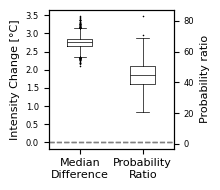

In [40]:
# ---------------------------------------------------------------------
# Bootstrap probability ratios for P(T >= observed)
# and plot as a box plot
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt


def bootstrap_probability_ratio(
    fact_values,
    cf_values,
    threshold,
    n_boot=2000,
    rng=None,
    correction=0.5,
):
    """
    Bootstrap the probability ratio

        PR = P_fact(T >= threshold) / P_cf(T >= threshold)

    using ensemble-member resampling with replacement.

    Parameters
    ----------
    fact_values : array-like
        Factual ensemble values for one day / region.
    cf_values : array-like
        Counterfactual ensemble values for one day / region.
    threshold : float
        Observed threshold temperature.
    n_boot : int
        Number of bootstrap resamples.
    rng : np.random.Generator or None
        Random number generator.
    correction : float
        Continuity correction to avoid division by zero when the
        counterfactual exceedance count is 0. Applied to both numerator
        and denominator counts as:
            p = (k + correction) / (n + 2 * correction)

    Returns
    -------
    pr_boot : ndarray
        Bootstrapped probability ratios.
    p_fact_boot : ndarray
        Bootstrapped factual exceedance probabilities.
    p_cf_boot : ndarray
        Bootstrapped counterfactual exceedance probabilities.
    """
    fact_values = np.asarray(fact_values).ravel()
    cf_values = np.asarray(cf_values).ravel()

    n_fact = fact_values.size
    n_cf = cf_values.size

    if rng is None:
        rng = np.random.default_rng()

    pr_boot = np.empty(n_boot, dtype=float)
    p_fact_boot = np.empty(n_boot, dtype=float)
    p_cf_boot = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        fact_sample = rng.choice(fact_values, size=n_fact, replace=True)
        cf_sample = rng.choice(cf_values, size=n_cf, replace=True)

        k_fact = np.sum(fact_sample >= threshold)
        k_cf = np.sum(cf_sample >= threshold)

        # Continuity-corrected exceedance probabilities
        p_fact = (k_fact + correction) / (n_fact + 2 * correction)
        p_cf = (k_cf + correction) / (n_cf + 2 * correction)

        p_fact_boot[i] = p_fact
        p_cf_boot[i] = p_cf
        pr_boot[i] = p_fact / p_cf

    return pr_boot, p_fact_boot, p_cf_boot


# ---------------------------------------------------------------------
# Use existing values from your earlier code
# ---------------------------------------------------------------------
# Assumes these already exist:
#   fact_values
#   cf_values
#   fact_truth_ger
#   TEXT_FS

boot_median_diff = fact_boot_medians - cf_boot_medians


t_obs = float(fact_truth_ger.values)

pr_boot, p_fact_boot, p_cf_boot = bootstrap_probability_ratio(
    fact_values=fact_values,
    cf_values=cf_values,
    threshold=t_obs,
    n_boot=2000,
    rng=np.random.default_rng(123),
    correction=0.5,
)

# Summary stats
pr_median = np.median(pr_boot)
pr_q025 = np.percentile(pr_boot, 2.5)
pr_q25 = np.percentile(pr_boot, 25)
pr_q75 = np.percentile(pr_boot, 75)
pr_q975 = np.percentile(pr_boot, 97.5)

print(f"Observed threshold: {t_obs:.3f} °C")
print(f"Median PR: {pr_median:.3f}")
print(f"IQR: [{pr_q25:.3f}, {pr_q75:.3f}]")
print(f"95% CI: [{pr_q025:.3f}, {pr_q975:.3f}]")

# ---------------------------------------------------------------------
# Box plot
# ---------------------------------------------------------------------


fig, ax1 = plt.subplots(figsize=(2.3, 2.0))

# -------------------------------------------------
# Left axis: median difference
# -------------------------------------------------
lw=0.5

box1 = ax1.boxplot(
    boot_median_diff,
    positions=[1],
    widths=0.4,
    vert=True,
    showfliers=True,
    flierprops={
        "marker": "x",
        "markersize": lw,
        "markerfacecolor": "k",
        "markeredgecolor": "k",
        "alpha": 1.0},
    patch_artist=False,
    medianprops={"linewidth": lw, "color": "black"},
    boxprops={"linewidth": lw},
    whiskerprops={"linewidth": lw},
    capprops={"linewidth": lw},
)

ax1.axhline(0, color="gray", linestyle="--", linewidth=1)

ax1.set_ylabel(
    "Intensity Change [°C]", #\n(Factual − Counterfactual)",
    fontsize=8
)

ax1.tick_params(axis="y", labelsize=6)


# -------------------------------------------------
# Right axis: probability ratio
# -------------------------------------------------
ax2 = ax1.twinx()

box2 = ax2.boxplot(
    pr_boot,
    positions=[2],
    widths=0.4,
    vert=True,
    showfliers=True,
    flierprops={
        "marker": "x",
        "markersize": lw,
        "markerfacecolor": "k",
        "markeredgecolor": "k",
        "alpha": 1.0},
    patch_artist=False,
    medianprops={"linewidth": lw, "color": "black"},
    boxprops={"linewidth": lw},
    whiskerprops={"linewidth": lw},
    capprops={"linewidth": lw},
)

ax2.axhline(1, color="gray", linestyle="--", linewidth=1)

ax2.set_ylabel(
    "Probability ratio", #\n$P_{fact}(T ≥ T_{obs}) / P_{cf}(T ≥ T_{obs})$",
    fontsize=8
)

ax2.tick_params(axis="y", labelsize=6)


# -------------------------------------------------
# X axis formatting
# -------------------------------------------------
ax1.set_xticks([1, 2])
ax1.set_xticklabels(
    ["Median\nDifference", "Probability\nRatio"],
    fontsize=8
)

#ax1.text(0.05, 0.93, "(d)", transform=ax1.transAxes, fontsize=text_fs)

plt.tight_layout()
plt.savefig("boxplot.pdf")
plt.show()

def bootstrap_intensity_shift(fact_values, cf_values, t_obs, n_boot=2000, rng=None):

    fact_values = np.asarray(fact_values)
    cf_values = np.asarray(cf_values)

    n_fact = len(fact_values)
    n_cf = len(cf_values)

    if rng is None:
        rng = np.random.default_rng()

    delta = np.empty(n_boot)

    for i in range(n_boot):

        fact_sample = rng.choice(fact_values, size=n_fact, replace=True)
        cf_sample = rng.choice(cf_values, size=n_cf, replace=True)

        p_fact = np.mean(fact_sample >= t_obs)
        t_cf_equiv = np.quantile(cf_sample, 1 - p_fact)

        delta[i] = t_obs - t_cf_equiv

    return delta


delta_boot = bootstrap_intensity_shift(
    fact_values,
    cf_values,
    t_obs,
    n_boot=2000,
    rng=np.random.default_rng(0)
)



/tmp/ipykernel_1759516/46735125.py:138: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x=float(cf_truth_ger.values),
/tmp/ipykernel_1759516/46735125.py:145: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x=float(fact_truth_ger.values),


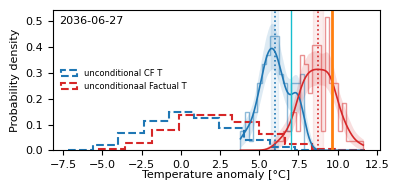

In [44]:
# ---------------------------------------------------------------------
# Plot histogram + KDE CI + mean/median/truth lines
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(4,2))

# Histograms as one-line outlines
ax.hist(
    cf_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1,
    alpha=0.5,
    color="tab:blue",
    #label="CF ensemble",
)
ax.hist(
    fact_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=1,
    alpha=0.5,
    color="tab:red",
    #label="Factual ensemble",
)

#############################
### risk-based Histograms ###
#############################
a_risk = trefht_le_cf_0627_ger.values.flatten()
b_risk = trefht_le_fact_0627_ger.values.flatten()

ax.hist(
    a_risk,
    density=True,
    histtype="step",
    linewidth=1.5,
    label="unconditional CF T",
    color="tab:blue",
    linestyle="--"
)

ax.hist(
    b_risk,
    density=True,
    histtype="step",
    linewidth=1.5,
    label="unconditionaal Factual T",
    color="tab:red",
    linestyle="--"
)

# KDE confidence intervals
ax.fill_between(
    x,
    cf_kde_low,
    cf_kde_high,
    color="tab:blue",
    alpha=0.15,
    linewidth=0,
    #label="CF KDE 95% CI",
)
ax.fill_between(
    x,
    fact_kde_low,
    fact_kde_high,
    color="tab:red",
    alpha=0.15,
    linewidth=0,
    #label="Factual KDE 95% CI",
)

# KDE lines from original ensemble
ax.plot(
    x,
    cf_kde,
    color="tab:blue",
    linewidth=1.2,
    #label="CF KDE",
)
ax.plot(
    x,
    fact_kde,
    color="tab:red",
    linewidth=1.2,
    #label="Factual KDE",
)

# Single ensemble mean vertical lines
#ax.axvline(
#    x=float(cf_single_ensemble_mean_ger.values),
#    color="tab:blue",
#    linestyle="--",
#    linewidth=1.0,
#    label="CF single\nensemble mean",
#)
#ax.axvline(
#    x=float(fact_single_ensemble_mean_ger.values),
#    color="tab:red",
#    linestyle="--",
#    linewidth=1.0,
#    label="Factual single\nensemble mean",
#)

# Bootstrap median vertical lines
ax.axvline(
    x=float(cf_boot_median),
    color="tab:blue",
    linestyle=":",
    linewidth=1.2,
    #label="CF bootstrap\nmedian",
)
ax.axvline(
    x=float(fact_boot_median),
    color="tab:red",
    linestyle=":",
    linewidth=1.2,
    #label="Factual bootstrap\nmedian",
)

# Optional: CI of the bootstrapped medians as shaded x-ranges
ax.axvspan(
    cf_median_ci_low,
    cf_median_ci_high,
    color="tab:blue",
    alpha=0.08,
)
ax.axvspan(
    fact_median_ci_low,
    fact_median_ci_high,
    color="tab:red",
    alpha=0.08,
)

# Truth lines
ax.axvline(
    x=float(cf_truth_ger.values),
    color="tab:cyan",
    linestyle="-",
    linewidth=1.0,
    #label="Circulation-nudged\nheatwave",
)
ax.axvline(
    x=float(fact_truth_ger.values),
    color="tab:orange",
    linestyle="-",
    linewidth=2.0,
    #label="Heatwave",
)

# Formatting
ax.set_xlabel("Temperature anomaly [°C]", fontsize=8, labelpad=0)
ax.set_ylabel("Probability density", fontsize=8)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8)
#ax.text(0.02, 0.9, f"(c)", transform=ax.transAxes, fontsize=TEXT_FS)
#x.text(0.02, 1.025, f"{DATE}", transform=ax.transAxes, fontsize=6)
ax.text(0.02, 0.9, f"{DATE}", transform=ax.transAxes, fontsize=8)


#ax.legend(
#    loc="center left",
#    bbox_to_anchor=(0.99, 0.5),
#    frameon=False,
#    fontsize=16,
#)

from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

class HandlerTwoColorPatch(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):

        r1 = Rectangle(
            (xdescent, ydescent), width/2, height,
            facecolor="tab:blue", alpha=0.15, transform=trans
        )
        r2 = Rectangle(
            (xdescent + width/2, ydescent), width/2, height,
            facecolor="tab:red", alpha=0.15, transform=trans
        )

        return [r1, r2]

ci_handle = object()

handles, labels = ax.get_legend_handles_labels()

handles.append(ci_handle)
#labels.append("KDE 95% CI")

ax.legend(
    handles,
    labels,
    handler_map={ci_handle: HandlerTwoColorPatch()},
    loc="center left",
    #bbox_to_anchor=(0.99, 0.5),
    frameon=False,
    fontsize=6,
)

#ci_patch = Patch(
#    facecolor="gray",
#    alpha=0.15,
#    label="KDE 95% CI"
#)

#handles, labels = ax.get_legend_handles_labels()
#handles.append(ci_patch)
#labels.append("KDE 95% CI")

#ax.legend(
#    handles,
#    labels,
#    loc="center left",
#    bbox_to_anchor=(0.99, 0.5),
#    frameon=False,
#    fontsize=16,
#)

fig.subplots_adjust(right=0.75)
plt.tight_layout()
plt.savefig("cond_distrs_and_risk_hists.pdf")
plt.show()

In [2]:
# indices of maximum absolute temperatures
#idx_abs = np.load("yearly_absolute_max_indices_ger.npy")
import xarray as xr
ds_1300 = xr.open_dataset("/work2/fl53wumy-llaae_ws_new/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_input_data/eth_test_trefht_data/TREFHT_day_b.e212.BHISTcmip6andSSP370cmip6.f09_g17.1300.nc")
ds_1300


<xarray.Dataset> Size: 20GB
Dimensions:    (time: 91615, bnds: 2, lon: 288, lat: 192)
Coordinates:
  * time       (time) object 733kB 1850-01-01 00:00:00 ... 2100-12-31 00:00:00
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 1MB ...
    TREFHT     (time, lat, lon) float32 20GB ...
Attributes:
    CDI:               Climate Data Interface version 1.9.6 (http://mpimet.mp...
    Conventions:       CF-1.0
    history:           Fri Sep 29 17:03:30 2023: cdo -O -mergetime /net/h2o/c...
    source:            CAM
    case:              b.e212.BHISTcmip6.f09_g17.1300
    logname:           beyerleu
    initial_file:      b.e212.B1850cmip6.f09_g17.001.cam.i.1300-01-01-00000.nc
    topography_file:   /cluster/work/climate/cesm/inputdata/atm/cam/topo/fv_0...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1
    CDO:               Climate Data Operators version 1.9.6 (http://mpimet.mp...

In [5]:
trefht_1300_abs = ut.get_ger_1d_data(ds_1300.TREFHT)
trefht_1300_abs

<xarray.DataArray 'TREFHT' (time: 91615)> Size: 733kB
array([277.9163743 , 277.40003626, 276.12869657, ..., 279.19536146,
       282.55132301, 285.26384028], shape=(91615,))
Coordinates:
  * time     (time) object 733kB 1850-01-01 00:00:00 ... 2100-12-31 00:00:00

In [12]:
# compute 5 day windows and compute mean 
ds_5day = trefht_1300_abs.resample(time="5D", label="left").mean()
print(ds_5day)
ds_5day = ds_5day.assign_coords(time=ds_5day.time + pd.Timedelta(days=2, hours=12))
ds_5day_jja = ds_5day.sel(time=ds_5day.time.dt.month.isin([6, 7, 8]))

<xarray.DataArray 'TREFHT' (time: 18323)> Size: 147kB
array([278.04761869, 280.21337129, 277.04075355, ..., 278.35046744,
       276.10902525, 280.7989015 ], shape=(18323,))
Coordinates:
  * time     (time) object 147kB 1850-01-01 00:00:00 ... 2100-12-27 00:00:00


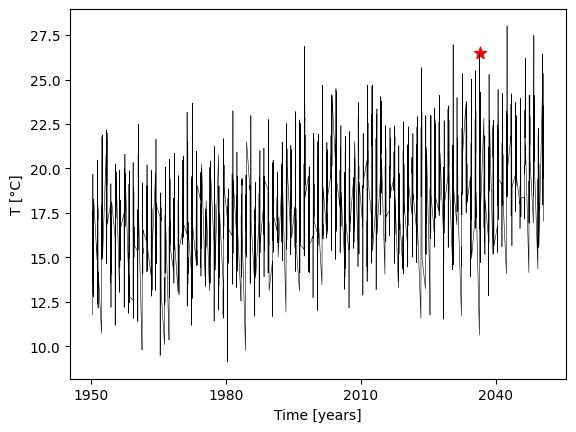

In [30]:
ds_5day_jja_celsius = ds_5day_jja.sel(time=slice("1950","2050"))-273.15
ds_5day_jja_celsius.plot(color='k', linestyle='-', linewidth=0.4)
plt.scatter(ds_5day_jja_celsius.sel(time="2036-06-27").time.values, ds_5day_jja_celsius.sel(time="2036-06-27").values, marker='*', s=80, color='red')
plt.ylabel("T [°C]")
plt.xlabel("Time [years]")
plt.savefig("GER_T_ts_absolute.pdf")


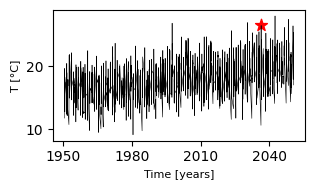

In [35]:
fig, ax = plt.subplots(figsize=(3.25, 2))

ds_5day_jja_celsius = ds_5day_jja.sel(time=slice("1950","2050")) - 273.15

ds_5day_jja_celsius.plot(
    ax=ax,
    color='k',
    linestyle='-',
    linewidth=0.4
)

ax.scatter(
    ds_5day_jja_celsius.sel(time="2036-06-27").time.values,
    ds_5day_jja_celsius.sel(time="2036-06-27").values,
    marker='*',
    s=80,
    color='red'
)

ax.set_ylabel("T [°C]", fontsize=8)
ax.set_xlabel("Time [years]", fontsize=8)

plt.tight_layout()
plt.savefig("GER_T_ts_absolute.pdf")